In [37]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [38]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [39]:
import driver; reload(driver)
from driver import RunResults

In [73]:
import results; reload(results)

base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split("trials", "random", "max")
model = trials.model("Diag")
metric = "pearson"
model.report(metric)

Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.


,seed,λ,pearson
0,0,0.010000,0.497649
1,1,0.001000,0.479133
2,2,0.001000,0.473343
3,3,3.162278,0.489046
4,4,0.003162,0.441147
5,5,3.162278,0.443696
6,6,10.000000,0.473355
7,7,3.162278,0.428743
8,8,0.031623,0.464339
9,9,1.000000,0.409544


In [78]:
# Get the distribution of how close the model correlations are to the output
vals = []
for seeds in range(10):
    for trains in range(5):
        corrs = model.extract(seed=seeds, train=trains, metric=metric).vld_corrs
        in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
        est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
        vals.append(est_out/in_out)
        
        

Text(0.5, 1.0, '|Cest-Cstar|/|Cin-Cstar|')

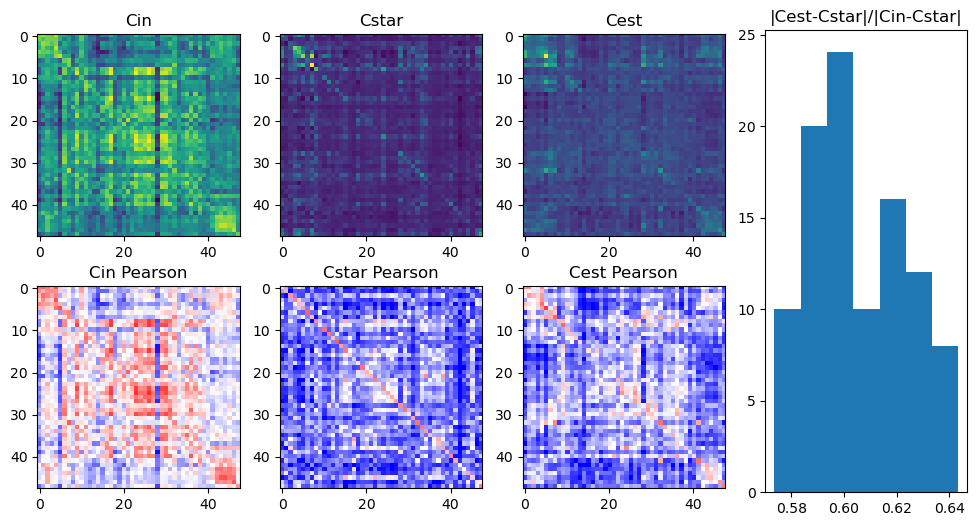

In [83]:
from matplotlib.gridspec import GridSpec
res = model.extract(seed=0, train=0, metric=metric)
gs = GridSpec(2,4)
fig = plt.figure(figsize=(12, 6))
# The first three columns of hte first row are Cin, Cstar, Cest
# Those of the second row are the corresponding pearson correlations
covs = res.vld
corrs = res.vld_corrs
for i, ds in enumerate(["Cin", "Cstar", "Cest"]):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(getattr(covs, ds))
    ax.set_title(ds)
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(corrs[ds], vmin=0, vmax=1, cmap="bwr")
    ax.set_title(f"{ds} Pearson")

ax = fig.add_subplot(gs[:, 3])
ax.hist(vals, bins=int(np.sqrt(len(vals))), density=True)
ax.set_title("|Cest-Cstar|/|Cin-Cstar|")

In [46]:
getattr(covs, "Cin").shape

(48, 48)